In [1]:
from moabb.analysis.results import Results
from moabb.evaluations import WithinSessionEvaluation
from moabb.paradigms import MotorImagery
from utils import print_results_summary

results = Results(  
    evaluation_class=WithinSessionEvaluation,  
    paradigm_class=MotorImagery,  
    hdf5_path="./benchmarks/results-pipelines_MI"
)

df = results.to_dataframe()  
print_results_summary(df)

Results Summary:
                                                                           mean    std  count
pipeline               dataset                                                               
CSP + LDA              BrainBot-PaperMethodology-3500ms                   0.267  0.061      5
                       BrainBot-PaperMethodology-3500ms-InitialFiltering  0.400  0.120      5
CSP + SVM Grid         BrainBot-PaperMethodology-3500ms                   0.266  0.051      5
                       BrainBot-PaperMethodology-3500ms-InitialFiltering  0.386  0.112      5
DLCSPauto + shLDA      BrainBot-PaperMethodology-3500ms                   0.257  0.067      5
                       BrainBot-PaperMethodology-3500ms-InitialFiltering  0.398  0.122      5
FgMDM                  BrainBot-PaperMethodology-3500ms                   0.360  0.077      5
                       BrainBot-PaperMethodology-3500ms-InitialFiltering  0.387  0.104      5
MDM                    BrainBot-PaperMethod

In [2]:
results = Results(  
    evaluation_class=WithinSessionEvaluation,  
    paradigm_class=MotorImagery,  
    hdf5_path="./benchmarks/results-pipelines_MI_tensorflow"
)

df = results.to_dataframe()  
print_results_summary(df)

Results Summary:
                                                                         mean    std  count
pipeline             dataset                                                               
Keras_DeepConvNet    BrainBot-PaperMethodology-3500ms                   0.259  0.031      5
                     BrainBot-PaperMethodology-3500ms-InitialFiltering  0.268  0.020      5
Keras_EEGITNet       BrainBot-PaperMethodology-3500ms                   0.240  0.051      5
                     BrainBot-PaperMethodology-3500ms-InitialFiltering  0.279  0.041      5
Keras_EEGNeX         BrainBot-PaperMethodology-3500ms                   0.255  0.022      5
                     BrainBot-PaperMethodology-3500ms-InitialFiltering  0.262  0.028      5
Keras_EEGNet_8_2     BrainBot-PaperMethodology-3500ms                   0.311  0.106      5
                     BrainBot-PaperMethodology-3500ms-InitialFiltering  0.326  0.084      5
Keras_ShallowConvNet BrainBot-PaperMethodology-3500ms          

### Notes
AUG Tang SVM Grid pipeline seems to get stuck (executed for 7+ hours for one subject without any visible progress) thus results are not complete

### Analysis

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Combine results from typical MI pipelines and Tensorflow pipelines
print("Reloading results to ensure we have all data...")
results_mi = Results(
    evaluation_class=WithinSessionEvaluation,
    paradigm_class=MotorImagery,
    hdf5_path="./benchmarks/results-pipelines_MI"
)
df_mi = results_mi.to_dataframe()
df_mi['type'] = 'Standard MI'

results_tf = Results(
    evaluation_class=WithinSessionEvaluation,
    paradigm_class=MotorImagery,
    hdf5_path="./benchmarks/results-pipelines_MI_tensorflow"
)
df_tf = results_tf.to_dataframe()
df_tf['type'] = 'Tensorflow'

# Concatenate
all_results = pd.concat([df_mi, df_tf], ignore_index=True)

# Define Channel Counts / Groups
def categorize_dataset(dataset_name):
    if 'BrainBot' in dataset_name:
        return 'BrainBot (Target)'
    elif '16' in dataset_name:
        return '16 Channels (Low Density)'
    else:
        return '60+ Channels (High Density)'

all_results['Channel Group'] = all_results['dataset'].apply(categorize_dataset)

print("Combined Data Shape:", all_results.shape)
print("Datasets:", all_results['dataset'].unique())

Reloading results to ensure we have all data...
Combined Data Shape: (130, 11)
Datasets: <StringArray>
['BrainBot-PaperMethodology-3500ms', 'BrainBot-PaperMethodology-3500ms-InitialFiltering']
Length: 2, dtype: str


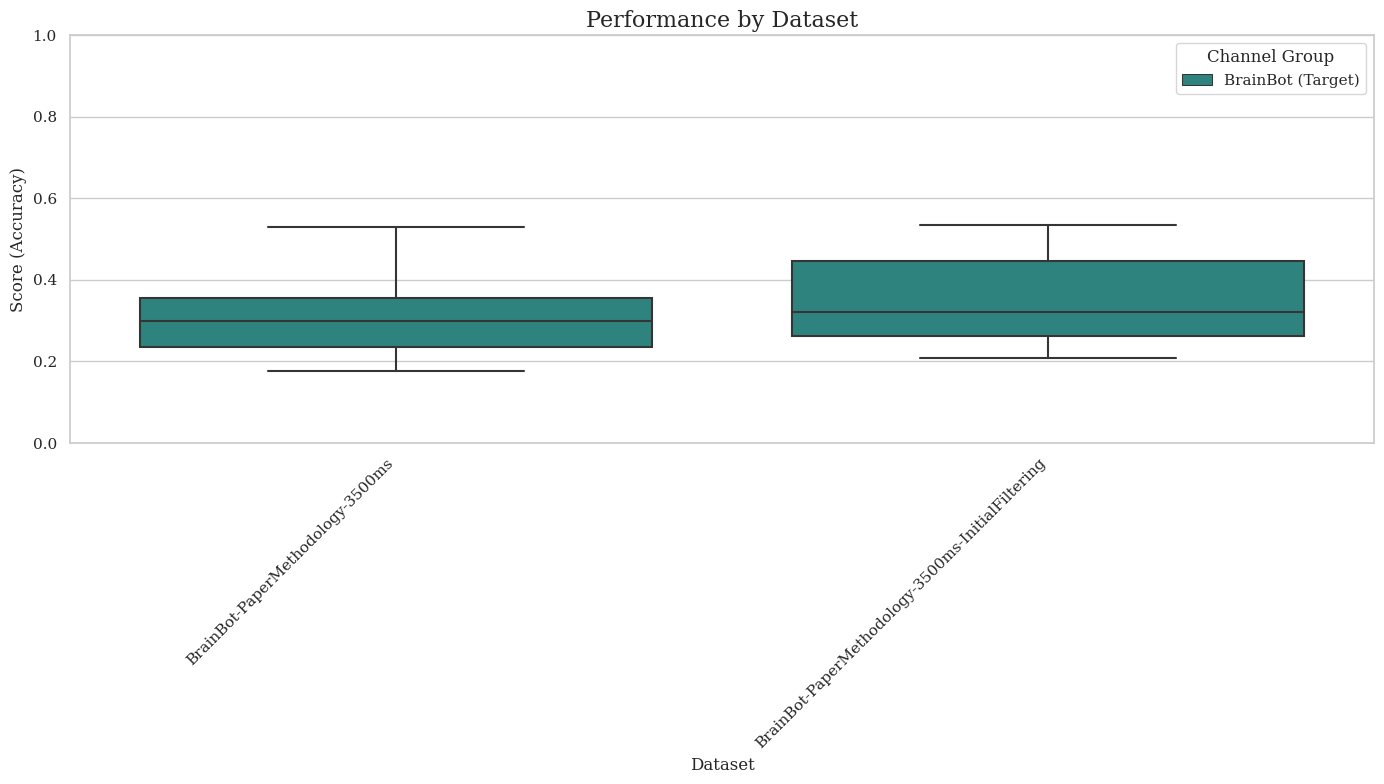

In [8]:
# 2. Dataset Performance Overview
plt.figure(figsize=(14, 8))
# Filter out the 7-class Weibo dataset for fair comparison or keep it but annotate
plot_data = all_results.copy()
# Rename for clarity in plot
plot_data['dataset_label'] = plot_data['dataset'].replace({
    'Weibo2014': 'Weibo2014 (7-class)',
    'Weibo2014_64_5-classes': 'Weibo 60ch (5-class)'
})

dataset_order = sorted(plot_data['dataset_label'].unique())

sns.boxplot(x='dataset', y='score', hue='Channel Group', data=plot_data, palette='viridis')
plt.title('Performance by Dataset', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Score (Accuracy)', fontsize=12)
plt.xlabel('Dataset', fontsize=12)
plt.legend(title='Channel Group', loc='upper right')
plt.ylim(0, 1)  # Assuming scores are between 0 and 1
plt.tight_layout()
plt.show()

=== Top Classifiers for BrainBot Dataset ===
                            mean       std  count
pipeline                                         
Tangent Space SVM Grid  0.393013  0.084150     10
Tangent Space LR        0.390451  0.081603     10
TS ElasticNet Grid      0.386231  0.075215     10
FgMDM                   0.373605  0.087475     10
Keras_ShallowConvNet    0.350142  0.121320     10
CSP + LDA               0.333307  0.113894     10
DLCSPauto + shLDA       0.327464  0.119178     10
CSP + SVM Grid          0.326267  0.103670     10
Keras_EEGNet_8_2        0.318566  0.090729     10
MDM                     0.304568  0.106747     10
Keras_DeepConvNet       0.263071  0.024688     10
Keras_EEGITNet          0.259356  0.048059     10
Keras_EEGNeX            0.258385  0.024181     10


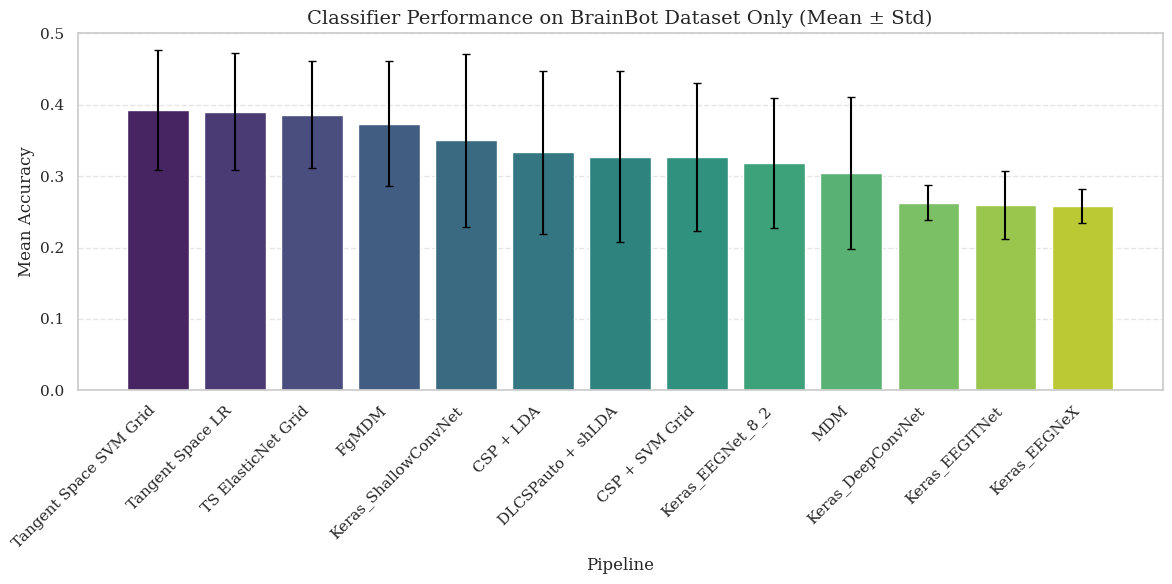

In [11]:

brainbot_performance = all_results.groupby('pipeline')['score'].agg(['mean', 'std', 'count']).sort_values('mean', ascending=False)

print("=== Top Classifiers for BrainBot Dataset ===")
print(brainbot_performance)

# Visualization for BrainBot
plt.figure(figsize=(12, 6))
sns.barplot(x=brainbot_performance.index, y='mean', data=brainbot_performance, palette='viridis')
plt.errorbar(x=range(len(brainbot_performance)), y=brainbot_performance['mean'], 
                yerr=brainbot_performance['std'], fmt='none', ecolor='black', capsize=3)
plt.title('Classifier Performance on BrainBot Dataset Only (Mean ± Std)', fontsize=14)
plt.ylabel('Mean Accuracy', fontsize=12)
plt.xlabel('Pipeline', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()